## Desafio 2 , NLP , Tatiana Arenas Suárez

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro dataset.
- Probar términos de interés y explicar similitudes en el espacio de embeddings (sacar conclusiones entre palabras similitudes y diferencias).
- Graficarlos.
- Obtener conclusiones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import multiprocessing
from gensim.models import Word2Vec
# le quitaré las stop words dado que contaminan mucho la extracción de similitud
import nltk
from nltk.corpus import stopwords

In [2]:
nltk.download('stopwords')
stop_words = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tatianaarenas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('../TP2/tectonics.txt', sep='/n', header=None)
df.head()

/var/folders/xz/wjn6xlys6nlcj2mvb023s1_m0000gn/T/ipykernel_94369/3313780371.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('../TP2/tectonics.txt', sep='/n', header=None)


,0
0,La idea de que los continentes van a la deriva...
1,Esta propuesta contrastaba por completo con la...
2,Esta opinión era respaldada por las pruebas re...
3,El concepto de un manto sólido indujo a la may...
4,"Durante este período, la opinión convencional ..."


In [4]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1205


## 1 Preprocesamiento

In [5]:

from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

filtered_tokens = [
    [word for word in sentence if word.lower() not in stop_words]
    for sentence in sentence_tokens
]    



## 2 Crear vectores con word2vec

In [6]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [7]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=10,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores 
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(filtered_tokens
)

In [8]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 1205
Cantidad de words distintas en el corpus: 426


In [9]:
top_n = 20
most_common_words = list(w2v_model.wv.key_to_index.keys())[:top_n]

print("Palabras más comunes:")
for i, word in enumerate(most_common_words, 1):
    print(f"{i}: {word}")

Palabras más comunes:
1: placas
2: manto
3: 2
4: placa
5: tierra
6: oceánico
7: figura
8: continental
9: oceánica
10: wegener
11: fondo
12: dorsal
13: litosfera
14: años
15: bordes
16: continentes
17: corteza
18: movimiento
19: expansión
20: deriva


## 3 Entrenar Embeddings 

In [10]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 131887.296875
Loss after epoch 1: 63203.28125
Loss after epoch 2: 61830.203125
Loss after epoch 3: 61440.90625
Loss after epoch 4: 60330.5
Loss after epoch 5: 62301.3125
Loss after epoch 6: 61329.15625
Loss after epoch 7: 61155.71875
Loss after epoch 8: 63884.9375
Loss after epoch 9: 62051.75
Loss after epoch 10: 63211.0
Loss after epoch 11: 62798.3125
Loss after epoch 12: 62426.125
Loss after epoch 13: 63799.375
Loss after epoch 14: 62554.5625
Loss after epoch 15: 60528.4375
Loss after epoch 16: 53939.5
Loss after epoch 17: 51682.5
Loss after epoch 18: 52873.0
Loss after epoch 19: 52931.625


(83573, 343800)

# 4- Probar con diferentes palabras del vocabulario la similaridad con otras:

In [11]:
words = ['volcánico', 'placa','tectónica','continental', 'tierra','oceánico' ]

In [12]:
for word in words:
# Palabras que MÁS se relacionan con...:
 print(f"Las palabras más silimares según el contexto a la palaba {word}")
 print(w2v_model.wv.most_similar(positive=[word], topn=10))
 print("***************************")

Las palabras más silimares según el contexto a la palaba volcánico
[('cordillera', 0.9944664835929871), ('lugares', 0.9927608370780945), ('dos', 0.9925890564918518), ('extiende', 0.991452693939209), ('fragmentos', 0.9899696707725525), ('actividad', 0.9890192747116089), ('denomina', 0.9887924790382385), ('caso', 0.9884566068649292), ('volcanes', 0.9881882667541504), ('bien', 0.9881241917610168)]
***************************
Las palabras más silimares según el contexto a la palaba placa
[('arrastre', 0.9828727841377258), ('empuje', 0.9720470309257507), ('subducción', 0.966383695602417), ('fuerza', 0.9490579962730408), ('fuerzas', 0.9398242831230164), ('capas', 0.9309550523757935), ('litosfera', 0.9265328049659729), ('astenosfera', 0.9238095283508301), ('zonas', 0.9234117269515991), ('produce', 0.9219344854354858)]
***************************
Las palabras más silimares según el contexto a la palaba tectónica
[('teoría', 0.9941689968109131), ('planeta', 0.9825757741928101), ('nuevas', 0.980

In [13]:
for word in words:
# Palabras que MÁS se relacionan con...:
 print(f"Las palabras MENOS silimares según el contexto a la palaba {word}")
 print(w2v_model.wv.most_similar(negative=[word], topn=10))
 print("***************************")

Las palabras MENOS silimares según el contexto a la palaba volcánico
[('polo', -0.6589059829711914), ('norte', -0.6891727447509766), ('magnético', -0.6991240382194519), ('fuerza', -0.7100269794464111), ('velocidad', -0.7486453056335449), ('centímetros', -0.7671996355056763), ('arrastre', -0.7730454802513123), ('islas', -0.7755229473114014), ('posición', -0.7912352085113525), ('magnéticos', -0.7923551797866821)]
***************************
Las palabras MENOS silimares según el contexto a la palaba placa
[('polo', -0.3963833749294281), ('islas', -0.4266848862171173), ('norte', -0.4272923767566681), ('magnético', -0.4357208013534546), ('sur', -0.4768359959125519), ('volcánicas', -0.5085778832435608), ('millones', -0.5162327885627747), ('cadena', -0.5226107239723206), ('años', -0.5391145348548889), ('hawaii', -0.5408832430839539)]
***************************
Las palabras MENOS silimares según el contexto a la palaba tectónica
[('islas', -0.4975399374961853), ('polo', -0.5020350217819214), 

## 5 Visualizar los vectores

In [14]:
from sklearn.decomposition import IncrementalPCA    
from sklearn.manifold import TSNE                   
import numpy as np                                  

def reduce_dimensions(model, num_dimensions = 2 ):
     
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)  

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [15]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
#fig.show(renderer="colab") # esto para plotly en colab
fig.show()

In [16]:
vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
#fig.show(renderer="colab") # esto para plotly en colab
fig.show() # esto para plotly en colab

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def reducir_y_graficar(model, key_word, num_similar=10, similares=True):
    if similares:
        similar_words = [word for word, _ in model.wv.most_similar(positive=[key_word], topn=num_similar)]
        string_similar = 'más'
    else:
        similar_words = [word for word, _ in model.wv.most_similar(negative=[key_word], topn=num_similar)]
        string_similar = 'menos'

    words = [key_word] + similar_words
    word_vectors = np.array([model.wv[word] for word in words])

    # Ajusto la perplexity para un número pequeño de muestras (sino da error)
    tsne = TSNE(n_components=2, random_state=0, perplexity=min(5, len(words) - 1))
    vectors_2d = tsne.fit_transform(word_vectors)

    # Creo un gráfico
    plt.figure(figsize=(10, 8))
    # Dibujo la palabra clave en rojo
    plt.scatter(vectors_2d[0, 0], vectors_2d[0, 1], c='red', label=key_word, s=100)  # Aumentar tamaño para destacar
    # Dibujo los vecinos en azul
    plt.scatter(vectors_2d[1:, 0], vectors_2d[1:, 1], c='blue', label='Vecinos')
    
    # Dibujo líneas entre la palabra clave y cada vecino
    # Queda mas claro si se dibujan líneas y mas vistoso si se dibujan líneas semi-transparentes
    for i in range(1, len(vectors_2d)):
        plt.plot([vectors_2d[0, 0], vectors_2d[i, 0]], [vectors_2d[0, 1], vectors_2d[i, 1]], 'k-', alpha=0.3)  # Líneas negras, semi-transparentes

    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]))
    plt.title(f'Visualización de \'{key_word}\' y sus 10 embeddings {string_similar} similares más cercanos')
    plt.legend()
    plt.show()

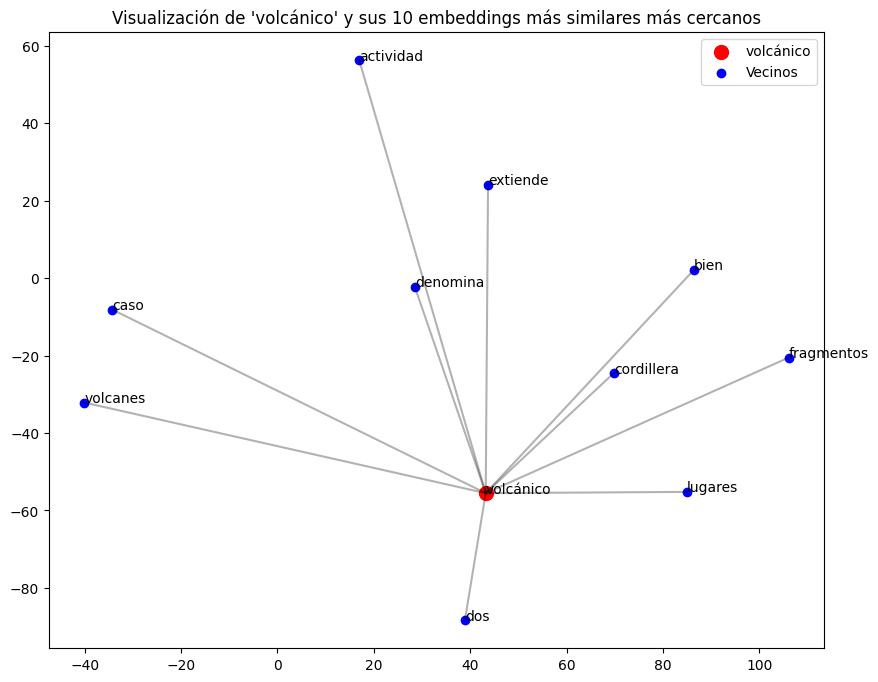

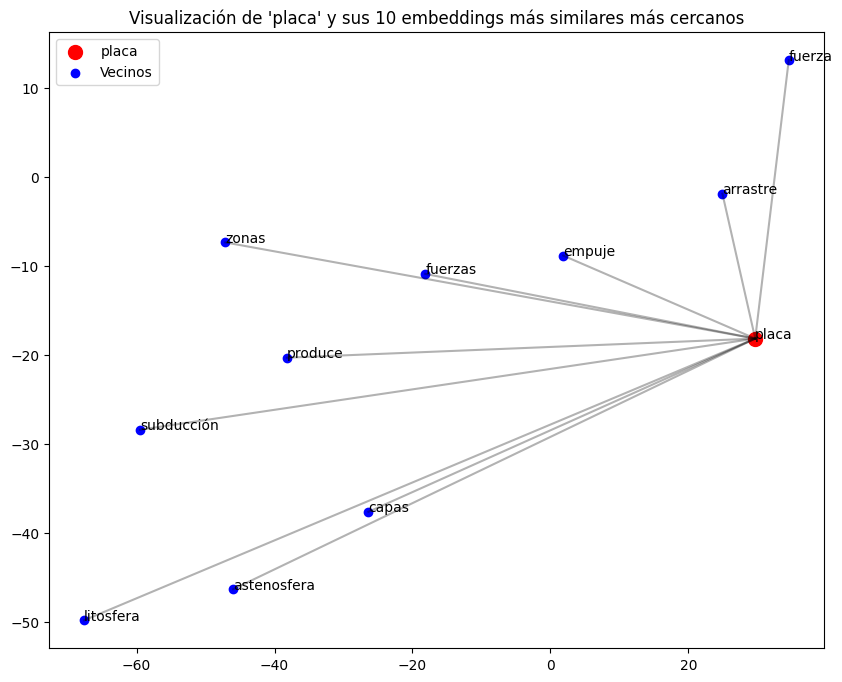

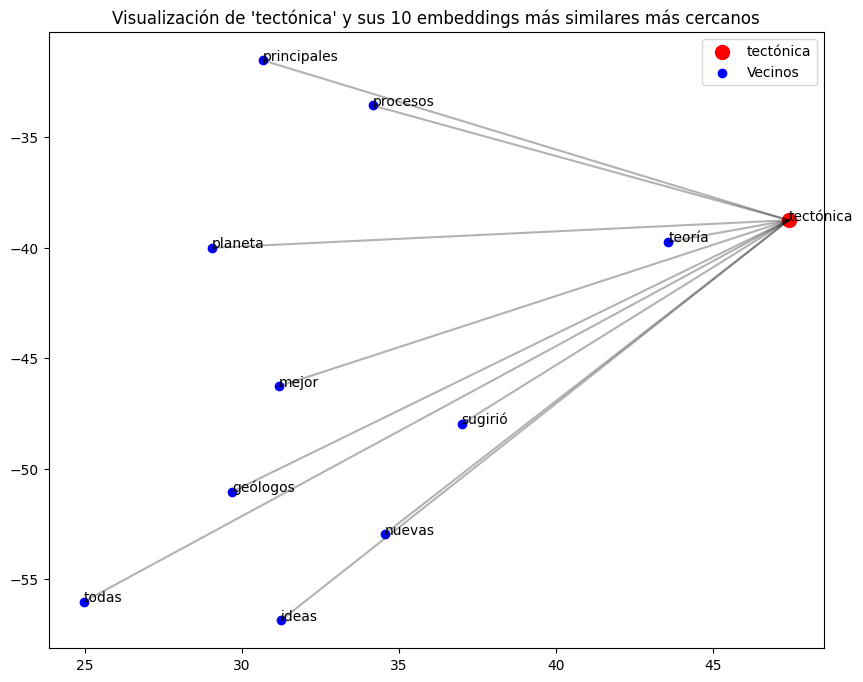

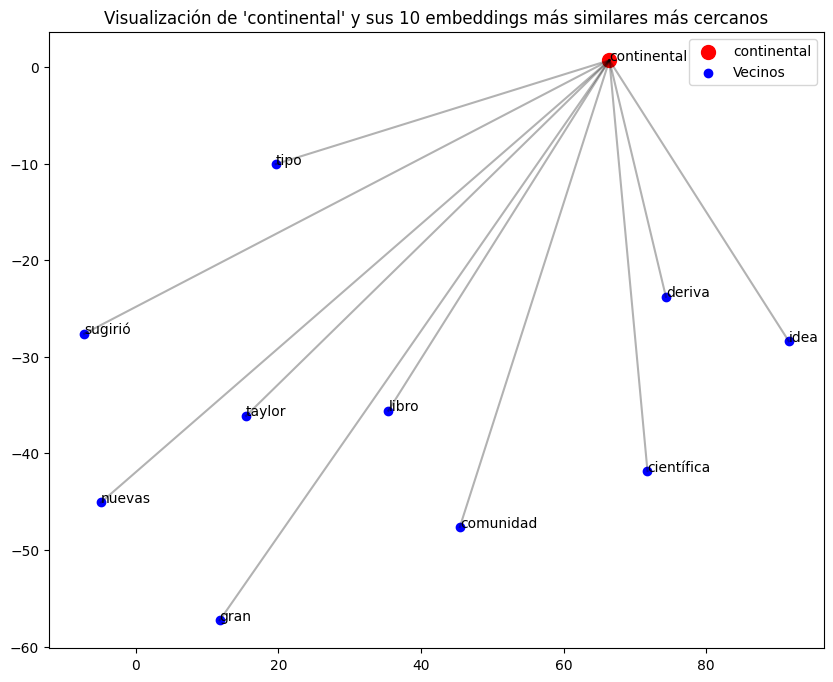

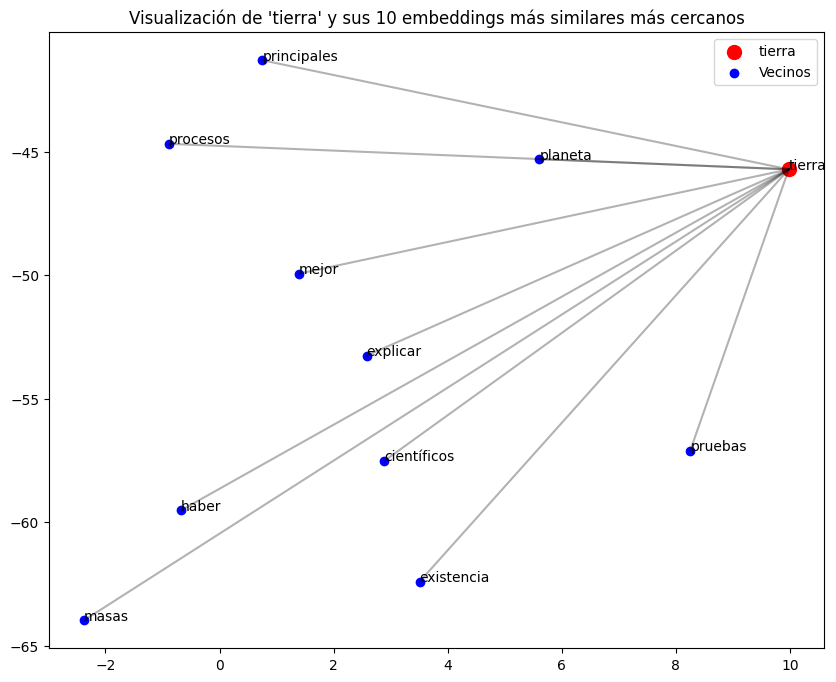

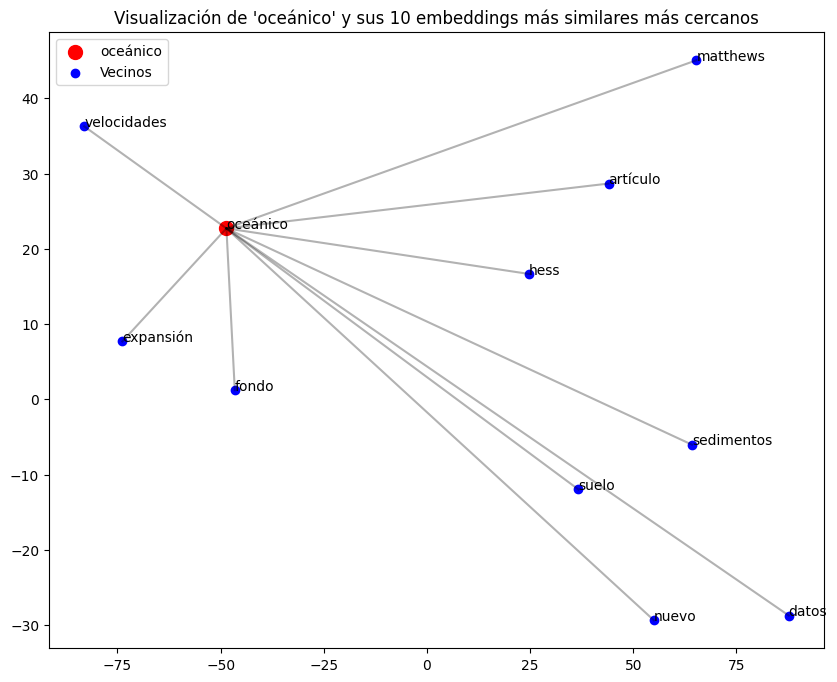

In [20]:
for word in words:
 reducir_y_graficar(w2v_model, word, similares=True)


## Conclusiones:

El corpus utilizado corresponde a un capítulo completo del libro Principios de Geología de Tarbuck. Eliminé las stop words del texto, ya que estas solían aparecer como las más "similares" debido al contexto general de las frases. También aumenté el parámetro window a 10 para ampliar el rango de contexto y así obtener palabras más relacionadas semánticamente. El capítulo se centra en la tectónica de placas, y al menos una de las diez palabras seleccionadas como más cercanas muestra una relación coherente tanto con la palabra clave como con el contexto temático.